# Additional metrics and averaging-window robustness

This notebook reproduces the appendix table comparing four belief-update metrics and the averaging-window robustness analyses. All results use the verified Step 3b timestamps and the volume-trusted hourly prices.

The additional-metrics table uses the paper setting $W=24$ hours. The robustness analysis then varies $W$ from 1 to 48 hours while holding the benchmark cohort and all other evaluation choices fixed.

In [1]:
%config InlineBackend.figure_format = 'png'

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, t, ttest_1samp
from tqdm import tqdm

ROOT          = Path('..').resolve()  # cruxbench root (run notebook from cruxbench/notebook/)
OUTPUTS_DIR   = ROOT / 'outputs'
HOURLY_CACHE  = ROOT / 'data/hourly_prices_trusted'
FIG_DIR       = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(ROOT))
from src.metrics import (
    before_after_prices, binary_entropy, kl_bernoulli, load_hourly,
    pivot_hour, significance_stars,
)

METRICS = ['ΔH', 'KL', '|Δp|', 'Δp²']
PLOT_METRICS = ['KL', 'ΔH', '|Δp|', 'Δp²']
METRIC_LABELS = {
    'KL':   r'$\widehat{\mathrm{VOI}}^{\mathrm{KL}}$',
    'ΔH':   r'$\widehat{\mathrm{VOI}}^{\Delta H}$',
    '|Δp|': r'$|\Delta p|$',
    'Δp²':  r'$\Delta p^2$',
}

plt.rcParams.update({
    'font.family':       'serif',
    'mathtext.fontset':  'cm',
    'axes.titlesize':    16,
    'axes.labelsize':    18,
    'xtick.labelsize':   15,
    'ytick.labelsize':   15,
    'legend.fontsize':   11,
    'figure.titlesize':  18,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})


In [2]:
GENERATORS = [
    ('claude-opus-4-6',        'claude-opus-4-6'),
    ('gpt-5.4',                'gpt-5.4'),
    ('gpt-3.5-turbo-1106',     'gpt-3.5-turbo-1106'),
    ('gemini-3.1-pro-preview', 'gemini-3.1-pro-preview'),
    ('llama-3.3-70B',          'together/meta-llama/Llama-3.3-70B-Instruct-Turbo'),
    ('qwen3-235B',             'together/Qwen/Qwen3-235B-A22B-Instruct-2507-tput'),
    ('deepseek-v3.1',          'together/deepseek-ai/DeepSeek-V3.1'),
    ('llama-3.1-8B',           'vllm/meta-llama/Llama-3.1-8B-Instruct'),
]

# Use the dated paper snapshot by default; set this to True to read the latest
# scores from Epoch instead.
USE_LATEST_ECI = False
ECI_URL = 'https://epoch.ai/data/eci_scores.csv'
ECI_SNAPSHOT_DATE = '2026-09-22'
ECI_SNAPSHOT_PATH = ROOT / 'data' / f'epoch_eci_scores_{ECI_SNAPSHOT_DATE}.csv'
ECI_MODEL_NAMES = {
    'claude-opus-4-6':        'Claude Opus 4.6',
    'gpt-5.4':                'GPT-5.4',
    'deepseek-v3.1':          'DeepSeek-V3.1',
    'qwen3-235B':             'Qwen3-235B-A22B-Instruct (Jul 2025)',
    'llama-3.3-70B':          'Llama 3.3 70B',
    'gpt-3.5-turbo-1106':     'GPT-3.5 Turbo (Nov 2023)',
    'llama-3.1-8B':           'Llama 3.1-8B',
    'gemini-3.1-pro-preview': 'Gemini 3.1 Pro',
}

eci_source = ECI_URL if USE_LATEST_ECI else ECI_SNAPSHOT_PATH
eci_data = pd.read_csv(eci_source).set_index('Model')
missing_eci = sorted(set(ECI_MODEL_NAMES.values()) - set(eci_data.index))
assert not missing_eci, f'Missing ECI rows: {missing_eci}'
EPOCH_SCORES = {
    model: float(eci_data.loc[epoch_name, 'eci'])
    for model, epoch_name in ECI_MODEL_NAMES.items()
}
print(f"ECI source: {'latest download' if USE_LATEST_ECI else 'paper snapshot ' + ECI_SNAPSHOT_DATE}")

MODEL_COLORS = {
    'claude-opus-4-6':        '#C44E52',
    'gpt-5.4':                '#55A868',
    'deepseek-v3.1':          '#4C72B0',
    'qwen3-235B':             '#8172B3',
    'llama-3.3-70B':          '#CCB974',
    'gpt-3.5-turbo-1106':     '#64B5CD',
    'llama-3.1-8B':           '#937860',
    'gemini-3.1-pro-preview': '#DA8BC3',
}
METRIC_COLORS = {
    'ΔH':   '#1f77b4',
    'KL':   '#d62728',
    '|Δp|': '#2ca02c',
    'Δp²':  '#9467bd',
}

dfs_raw = {name: pd.read_json(OUTPUTS_DIR / sub / 'resolved.json')
           for name, sub in GENERATORS}
print(f'loaded {len(dfs_raw)} generators')

market_registry = {}
for df in dfs_raw.values():
    for _, row in df.iterrows():
        mid = int(row['id'])
        if mid not in market_registry:
            market_registry[mid] = row
print(f'{len(market_registry)} unique markets')


ECI source: paper snapshot 2026-09-22
loaded 8 generators


293 unique markets


In [3]:
missing = [mid for mid in market_registry
           if not (HOURLY_CACHE / f'{mid}.json').exists()]
if missing:
    raise FileNotFoundError(
        f'{len(missing)} trusted price histories are missing. '
        'Run: python data_collection/build_trusted_prices.py'
    )

hourly = {mid: load_hourly(mid, HOURLY_CACHE) for mid in market_registry}
hourly = {mid: s for mid, s in hourly.items() if s is not None and len(s) > 0}
print(f'loaded {len(hourly)} hourly series')


loaded 293 hourly series


In [4]:
def metrics_at_W(df_r, W):
    """Per-subquestion ΔH/KL/|Δp|/Δp² + random and oracle baselines over the active window."""
    rows = []
    for _, row in df_r.iterrows():
        mid = int(row['id'])
        ser = hourly.get(mid)
        q = row['question']
        if ser is None or not isinstance(q, str):
            continue
        pb_s, pa_s = before_after_prices(ser, W)
        for w in row['active_windows']:
            subs = w.get('subquestions', [])
            s = subs[0] if subs else {}

            ws = pd.to_datetime(w['start'], utc=True).floor('1h')
            we = pd.to_datetime(w['end'],   utc=True).floor('1h') + pd.Timedelta(hours=23)
            in_win = (pb_s.index >= ws) & (pb_s.index <= we)
            pb_w = pb_s[in_win].values
            pa_w = pa_s[in_win].values
            mask = ~(pd.isna(pb_w) | pd.isna(pa_w))
            if mask.sum() == 0:
                continue
            pb_v = pb_w[mask]; pa_v = pa_w[mask]
            per_voi = binary_entropy(pb_v) - binary_entropy(pa_v)
            per_kl  = kl_bernoulli(pa_v, pb_v)
            per_dp  = np.abs(pa_v - pb_v)
            per_d2  = (pa_v - pb_v) ** 2

            # Unresolvable cruxes and missing prices score 0.
            dH = kl = dp = d2 = 0.0
            rd = s.get('resolution_datetime', '')
            if rd and s.get('resolvable'):
                pv = pivot_hour(pd.to_datetime(rd, utc=True))
                pr = pb_s.get(pv, np.nan)
                po = pa_s.get(pv, np.nan)
                if not (pd.isna(pr) or pd.isna(po)):
                    dH = float(binary_entropy(pr) - binary_entropy(po))
                    kl = float(kl_bernoulli(po, pr))
                    dp = float(abs(po - pr))
                    d2 = float((po - pr) ** 2)

            rows.append(dict(
                q=q, mid=mid, period_idx=w.get('period_idx'),
                dH=dH, kl=kl, dp=dp, d2=d2,
                **{'rand_ΔH':  float(per_voi.mean()), 'oracle_ΔH':  float(per_voi.max())},
                rand_KL=float(per_kl.mean()),    oracle_KL=float(per_kl.max()),
                **{'rand_|Δp|':  float(per_dp.mean()), 'oracle_|Δp|':  float(per_dp.max()),
                   'rand_Δp²':   float(per_d2.mean()), 'oracle_Δp²':   float(per_d2.max())}
            ))
    return pd.DataFrame(rows)

def _p_gt(sub_vals, rand_vals):
    diff = np.asarray(sub_vals) - np.asarray(rand_vals)
    if len(diff) < 2:
        return np.nan
    return float(ttest_1samp(diff, 0, alternative='greater').pvalue)


## 1. Additional metric results

The table reports KL divergence, entropy reduction, absolute price change, and squared price change using the same 24-hour before/after averaging window and the same 293 markets. Confidence intervals are t-based intervals over markets. Rank is among the eight generators, and significance is relative to the corresponding random baseline.

In [5]:
W = 24
raw = {name: metrics_at_W(df, W) for name, df in dfs_raw.items()}
print(f'W={W:>3}h  n_per_model={len(next(iter(raw.values())))}')

PAPER_NAMES = {
    'gemini-3.1-pro-preview': 'Gemini-3.1-Pro-Preview',
    'claude-opus-4-6': 'Claude-Opus-4.6',
    'gpt-5.4': 'GPT-5.4',
    'llama-3.3-70B': 'Llama-3.3-70B',
    'deepseek-v3.1': 'DeepSeek-V3.1',
    'qwen3-235B': 'Qwen3-235B-A22B',
    'llama-3.1-8B': 'Llama-3.1-8B-Instruct',
    'gpt-3.5-turbo-1106': 'GPT-3.5-Turbo',
}

def _mean_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    mean = float(values.mean())
    half_width = float(t.ppf((1 + confidence) / 2, len(values) - 1)
                       * values.std(ddof=1) / np.sqrt(len(values)))
    return mean, mean - half_width, mean + half_width


METRIC_SPECS = {
    'VOI^KL (bits)': {
        'value': 'kl', 'random': 'rand_KL', 'oracle': 'oracle_KL', 'p_key': 'KL'
    },
    'VOI^ΔH (bits)': {
        'value': 'dH', 'random': 'rand_ΔH', 'oracle': 'oracle_ΔH', 'p_key': 'ΔH'
    },
    '|Δp|': {
        'value': 'dp', 'random': 'rand_|Δp|', 'oracle': 'oracle_|Δp|', 'p_key': '|Δp|'
    },
    'Δp²': {
        'value': 'd2', 'random': 'rand_Δp²', 'oracle': 'oracle_Δp²', 'p_key': 'Δp²'
    },
}

def _fmt3(value):
    # Avoid displaying a rounded confidence bound as negative zero.
    return f'{0.0 if abs(value) < 0.0005 else value:.3f}'

p_values = {
    spec['p_key']: {model: _p_gt(frame[spec['value']], frame[spec['random']])
                    for model, frame in raw.items()}
    for spec in METRIC_SPECS.values()
}

reference = next(iter(raw.values()))
assert all(len(frame) == 293 for frame in raw.values())
for spec in METRIC_SPECS.values():
    for frame in raw.values():
        assert np.allclose(frame[spec['random']], reference[spec['random']])
        assert np.allclose(frame[spec['oracle']], reference[spec['oracle']])

means = pd.DataFrame({
    metric: {model: frame[spec['value']].mean() for model, frame in raw.items()}
    for metric, spec in METRIC_SPECS.items()
})
ranks = means.rank(ascending=False, method='min').astype(int)
model_order = means['VOI^KL (bits)'].sort_values(ascending=False).index

columns = [('Model', '')]
for metric in METRIC_SPECS:
    columns.extend([(metric, 'Estimate'), (metric, '95% CI'), (metric, 'Rank')])

rows = []
for model in model_order:
    row = {('Model', ''): PAPER_NAMES[model]}
    for metric, spec in METRIC_SPECS.items():
        mean, lo, hi = _mean_ci(raw[model][spec['value']])
        stars = significance_stars(p_values[spec['p_key']][model])
        row[(metric, 'Estimate')] = f'{_fmt3(mean)}{stars}'
        row[(metric, '95% CI')] = f'[{_fmt3(lo)}, {_fmt3(hi)}]'
        row[(metric, 'Rank')] = str(ranks.loc[model, metric])
    rows.append(row)

for label, baseline_key in [('Random baseline', 'random'), ('Oracle', 'oracle')]:
    row = {('Model', ''): label}
    for metric, spec in METRIC_SPECS.items():
        mean, lo, hi = _mean_ci(reference[spec[baseline_key]])
        row[(metric, 'Estimate')] = _fmt3(mean)
        row[(metric, '95% CI')] = f'[{_fmt3(lo)}, {_fmt3(hi)}]'
        row[(metric, 'Rank')] = '—'
    rows.append(row)

additional_metrics = pd.DataFrame(rows, columns=pd.MultiIndex.from_tuples(columns))

def _bold_metric_leaders(_):
    styles = pd.DataFrame('', index=additional_metrics.index, columns=additional_metrics.columns)
    for metric in METRIC_SPECS:
        leader = means[metric].idxmax()
        row_idx = list(model_order).index(leader)
        styles.loc[row_idx, (metric, 'Estimate')] = 'font-weight: bold'
    return styles

print(f'Additional metric results by model (n={len(reference)}, W={W}h)')
display(additional_metrics.style.hide(axis='index').apply(_bold_metric_leaders, axis=None))


W= 24h  n_per_model=293
Additional metric results by model (n=293, W=24h)


## 2. Metrics across averaging windows

Each panel varies the number of hours averaged on either side of the resolution timestamp. The vertical line marks the paper setting, $W=24$ hours.

In [6]:
def aggregate_at_W(W):
    """For each model, mean metric and mean random baseline across all active windows at this W."""
    rolling = {}
    for mid, s in hourly.items():
        if len(s) >= W:
            rmean = s.rolling(window=W, min_periods=W).mean()
            rolling[mid] = (rmean, rmean.shift(-W))

    out = {}
    for name, df in dfs_raw.items():
        sums      = {k: 0.0 for k in METRICS}
        rand_sums = {k: 0.0 for k in METRICS}
        n = 0
        for _, row in df.iterrows():
            mid = int(row['id'])
            if mid not in rolling:
                continue
            pb_s, pa_s = rolling[mid]
            q = row['question']
            if not isinstance(q, str):
                continue
            for w in row['active_windows']:
                ws = pd.to_datetime(w['start'], utc=True).floor('1h')
                we = pd.to_datetime(w['end'],   utc=True).floor('1h') + pd.Timedelta(hours=23)
                in_win = (pb_s.index >= ws) & (pb_s.index <= we)
                pb_w = pb_s[in_win].values; pa_w = pa_s[in_win].values
                mask = ~(pd.isna(pb_w) | pd.isna(pa_w))
                if mask.sum() == 0:
                    continue
                pb_v = pb_w[mask]; pa_v = pa_w[mask]
                rand_sums['ΔH']   += float((binary_entropy(pb_v) - binary_entropy(pa_v)).mean())
                rand_sums['KL']   += float(kl_bernoulli(pa_v, pb_v).mean())
                rand_sums['|Δp|'] += float(np.abs(pa_v - pb_v).mean())
                rand_sums['Δp²']  += float(((pa_v - pb_v) ** 2).mean())

                subs = w.get('subquestions', [])
                s = subs[0] if subs else {}
                rd = s.get('resolution_datetime', '')
                dH = kl = dp = d2 = 0.0
                if rd and s.get('resolvable'):
                    pv = pivot_hour(pd.to_datetime(rd, utc=True))
                    pr = pb_s.get(pv, np.nan); po = pa_s.get(pv, np.nan)
                    if not (pd.isna(pr) or pd.isna(po)):
                        dH = float(binary_entropy(pr) - binary_entropy(po))
                        kl = float(kl_bernoulli(po, pr))
                        dp = float(abs(po - pr))
                        d2 = float((po - pr) ** 2)
                sums['ΔH']   += dH
                sums['KL']   += kl
                sums['|Δp|'] += dp
                sums['Δp²']  += d2
                n += 1
        if n == 0:
            row_out = {k: np.nan for k in METRICS}
            row_out.update({f'rand_{k}': np.nan for k in METRICS})
            row_out['n'] = 0
        else:
            row_out = {k: sums[k] / n for k in METRICS}
            row_out.update({f'rand_{k}': rand_sums[k] / n for k in METRICS})
            row_out['n'] = n
        out[name] = row_out
    return out

def full_sweep(W_list):
    rows = []
    for W in tqdm(W_list, desc='W sweep'):
        out = aggregate_at_W(W)
        for name, vals in out.items():
            rows.append({'model': name, 'W': W, **vals})
    return pd.DataFrame(rows)


W_HOURS = list(range(1, 49))   # every hour, 1..48
sweep_df = full_sweep(W_HOURS)
sweep_df.head()


,model,W,ΔH,KL,|Δp|,Δp²,rand_ΔH,rand_KL,rand_|Δp|,rand_Δp²,n
0,claude-opus-4-6,1,0.000591,0.000439,0.003105,0.000086,0.000389,0.000753,0.002837,0.000174,293
1,gpt-5.4,1,0.000238,0.000718,0.003460,0.000171,0.000389,0.000753,0.002837,0.000174,293
2,gpt-3.5-turbo-1106,1,0.000327,0.000260,0.002549,0.000071,0.000389,0.000753,0.002837,0.000174,293
3,gemini-3.1-pro-preview,1,-0.001024,0.000339,0.002982,0.000078,0.000389,0.000753,0.002837,0.000174,293
4,llama-3.3-70B,1,-0.000494,0.000355,0.002738,0.000078,0.000389,0.000753,0.002837,0.000174,293


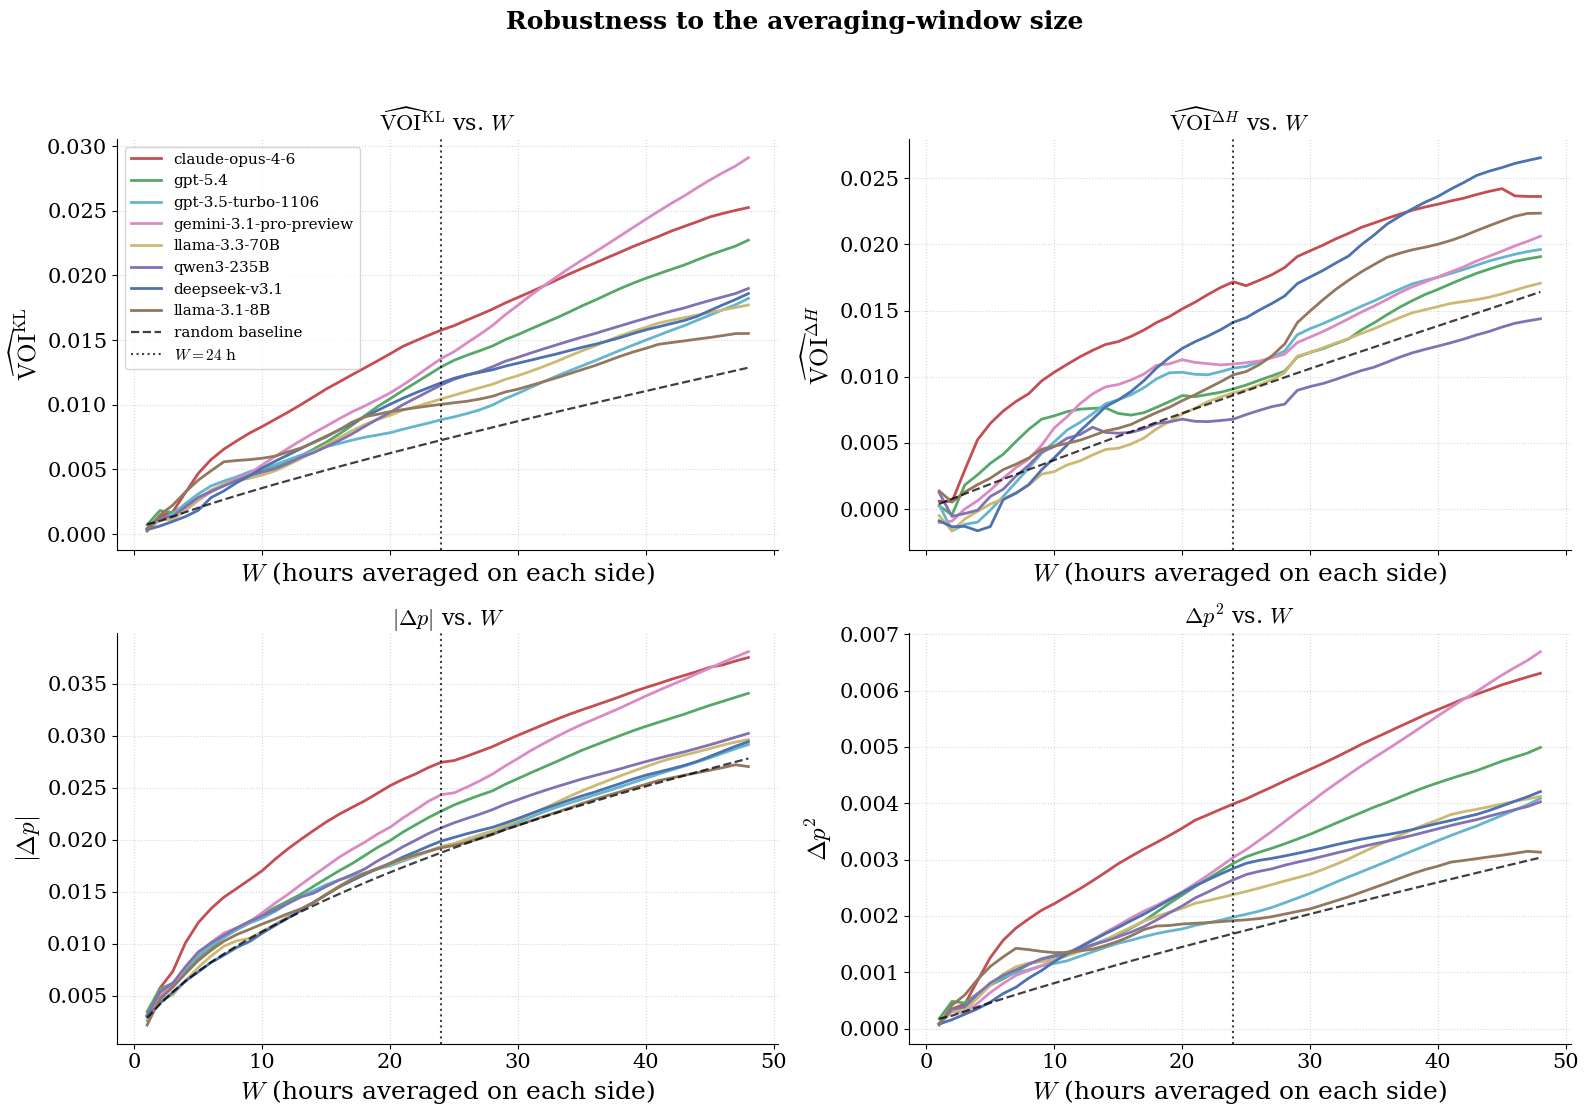

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
for ax, metric in zip(axes.flat, PLOT_METRICS):
    rand_col = f'rand_{metric}'
    for name in dfs_raw:
        sub = sweep_df[sweep_df['model'] == name].sort_values('W')
        ax.plot(sub['W'], sub[metric], lw=2.0, label=name, color=MODEL_COLORS[name])
    ys_rand = sweep_df.groupby('W')[rand_col].mean().sort_index()
    ax.plot(ys_rand.index, ys_rand.values, ls='--', lw=1.6, color='black',
            alpha=0.75, label='random baseline')
    ax.axvline(24, color='black', ls=':', lw=1.5, alpha=0.75,
               label=r'$W=24$ h')
    metric_label = METRIC_LABELS[metric]
    ax.set_title(rf'{metric_label} vs. $W$', fontsize=16)
    ax.set_xlabel(r'$W$ (hours averaged on each side)', fontsize=18)
    ax.set_ylabel(metric_label, fontsize=18)
    ax.tick_params(axis='both', labelsize=15)
    ax.grid(True, ls=':', alpha=0.5)
axes[0, 0].legend(loc='upper left', fontsize=11, frameon=True)
fig.suptitle('Robustness to the averaging-window size',
             fontsize=18, fontweight='bold', y=1.01)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIG_DIR / 'metrics_vs_w.pdf', bbox_inches='tight')
plt.show()


## 3. Correlation and ranking stability

Panel (a) shows the correlation between each metric and the Epoch Capability Index across averaging windows. Stars mark correlations with $p<0.05$. Panel (b) compares model rankings at each $W$ with the ranking at the paper setting, $W=24$ hours.

In [8]:
pearson_by_metric = {m: [] for m in METRICS}
p_pearson = {m: [] for m in METRICS}

for W in W_HOURS:
    sub = sweep_df[sweep_df['W'] == W].set_index('model')
    sub = sub.loc[sub.index.isin(EPOCH_SCORES)].copy()
    sub['epoch'] = [EPOCH_SCORES[mod] for mod in sub.index]
    for metric in METRICS:
        vals = sub[metric].values
        if np.any(np.isnan(vals)) or sub['epoch'].std() == 0 or np.nanstd(vals) == 0:
            pearson_by_metric[metric].append(np.nan)
            p_pearson[metric].append(np.nan)
            continue
        pr, pr_p = pearsonr(sub['epoch'], vals)
        pearson_by_metric[metric].append(pr)
        p_pearson[metric].append(pr_p)


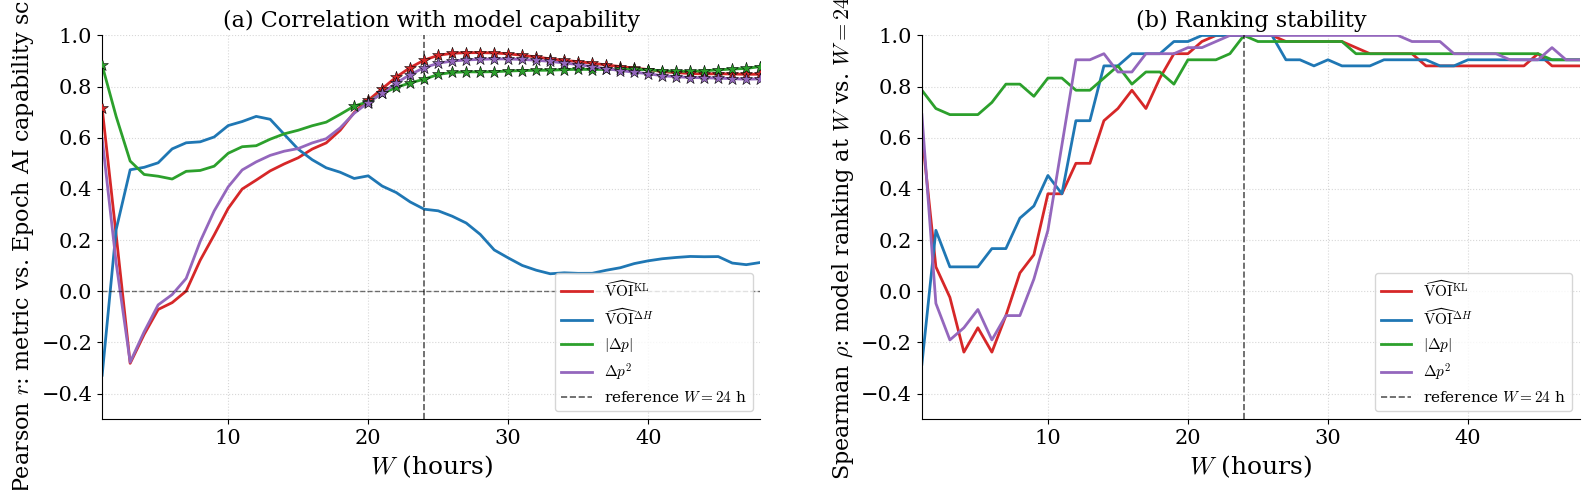

In [9]:
W_PRIMARY = 24    # reference W
W_MIN     = 1

def rank_stability_vs_W(sweep_df, metric, W_primary):
    """Spearman ρ between model rankings at W_primary and at every W."""
    ref = (sweep_df[sweep_df['W'] == W_primary]
             .set_index('model')[metric]
             .rank(ascending=False, method='average'))
    out = {}
    for W in sorted(sweep_df['W'].unique()):
        cur = (sweep_df[sweep_df['W'] == W]
                 .set_index('model')[metric]
                 .rank(ascending=False, method='average'))
        shared = ref.index.intersection(cur.index)
        if len(shared) < 3:
            out[W] = np.nan; continue
        rho, _ = spearmanr(ref.loc[shared], cur.loc[shared])
        out[W] = rho
    return pd.Series(out, name=metric)

stability_full = pd.DataFrame({m: rank_stability_vs_W(sweep_df, m, W_PRIMARY) for m in METRICS})
stability      = stability_full.loc[stability_full.index >= W_MIN]

fig, (ax_corr, ax_rank) = plt.subplots(1, 2, figsize=(16, 5))

for metric in PLOT_METRICS:
    ys = pearson_by_metric[metric]
    ax_corr.plot(W_HOURS, ys, lw=2.0, color=METRIC_COLORS[metric],
                 label=METRIC_LABELS[metric])
    sig_W = [W for W, p in zip(W_HOURS, p_pearson[metric])
             if p is not None and not np.isnan(p) and p < 0.05]
    sig_y = [y for y, p in zip(ys, p_pearson[metric])
             if p is not None and not np.isnan(p) and p < 0.05]
    if sig_W:
        ax_corr.scatter(sig_W, sig_y, marker='*', s=80,
                        color=METRIC_COLORS[metric], edgecolors='black',
                        linewidths=0.4, zorder=5)
ax_corr.axhline(0, color='black', lw=1.0, ls='--', alpha=0.55)
ax_corr.axvline(W_PRIMARY, color='black', ls='--', lw=1.2, alpha=0.65,
                label=rf'reference $W={W_PRIMARY}$ h')
ax_corr.set_xlim(W_MIN, max(W_HOURS))
ax_corr.set_ylim(-0.5, 1.0)
ax_corr.set_xlabel(r'$W$ (hours)', fontsize=18)
ax_corr.set_ylabel(r'Pearson $r$: metric vs. Epoch AI capability score', fontsize=16)
ax_corr.set_title('(a) Correlation with model capability', fontsize=16)
ax_corr.tick_params(axis='both', labelsize=15)
ax_corr.grid(True, ls=':', alpha=0.5)
ax_corr.legend(loc='lower right', fontsize=11, frameon=True)

for metric in PLOT_METRICS:
    ax_rank.plot(stability.index, stability[metric], lw=2.0,
                 color=METRIC_COLORS[metric], label=METRIC_LABELS[metric])
ax_rank.axvline(W_PRIMARY, color='black', ls='--', lw=1.2, alpha=0.65,
                label=rf'reference $W={W_PRIMARY}$ h')
ax_rank.set_xlim(W_MIN, stability.index.max())
ax_rank.set_ylim(-0.5, 1.0)
ax_rank.set_xlabel(r'$W$ (hours)', fontsize=18)
ax_rank.set_ylabel(rf'Spearman $\rho$: model ranking at $W$ vs. $W={W_PRIMARY}$ h', fontsize=16)
ax_rank.set_title('(b) Ranking stability', fontsize=16)
ax_rank.tick_params(axis='both', labelsize=15)
ax_rank.grid(True, ls=':', alpha=0.5)
ax_rank.legend(loc='lower right', fontsize=11, frameon=True)

fig.tight_layout(w_pad=5.0)
fig.savefig(FIG_DIR / 'window_correlation_rank_stability.pdf', bbox_inches='tight')
plt.show()
